#  Breast Cancer Classification using Support Vector Machines

## Project Overview

This project applies multiple Support Vector Machine (SVM) variants to classify breast tumors as **Benign** or **Malignant** using the Wisconsin Breast Cancer Diagnostic Dataset.

The notebook explores different SVM kernels, compares their performance with Logistic Regression, and investigates how kernel choice and hyperparameter tuning affect classification accuracy.

---

### Objectives

- Perform exploratory data analysis (EDA)
- Prepare and preprocess the data
- Build a Logistic Regression baseline
- Train Linear, Polynomial and RBF SVM models
- Compare model performance using Cross Validation
- Tune hyperparameters using GridSearchCV
- Evaluate the best model using multiple classification metrics

#  Dataset

The Breast Cancer Wisconsin Diagnostic Dataset contains measurements computed from digitized images of breast mass cell nuclei.

Target Variable:

- **B (0)** → Benign (Non-Cancerous)
- **M (1)** → Malignant (Cancerous)

The dataset contains 569 observations and 30 numerical features describing tumor characteristics.

In [1]:
import pandas as pd
data = pd.read_csv("/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv")
data.shape

(569, 33)

#  Exploratory Data Analysis

Before building machine learning models, we inspect the dataset to understand:

- Dataset dimensions
- Feature types
- Missing values
- Class distribution
- Statistical summary

This helps identify potential preprocessing requirements before model training.

In [2]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
data["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

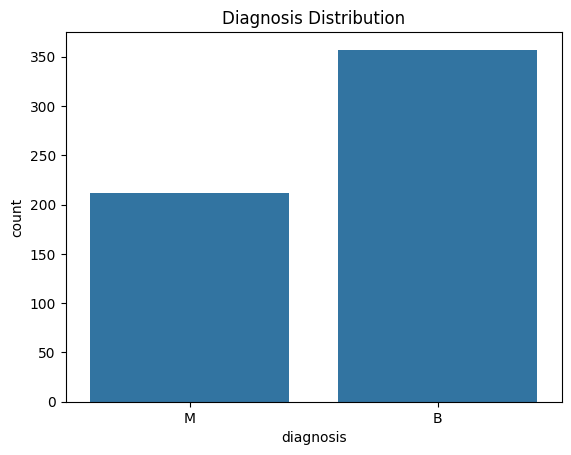

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="diagnosis",
    data=data
)

plt.title("Diagnosis Distribution")

plt.show()

#  Data Preprocessing

To prepare the dataset:

- Remove unnecessary columns
- Encode the diagnosis labels
- Split features and target
- Create training and testing datasets

In [8]:
data = data.drop(columns=["id","Unnamed: 32"])

In [9]:
data["diagnosis"] = data["diagnosis"].map({
    "B":0,
    "M":1
})

In [10]:
data["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [11]:
X = data.drop("diagnosis",axis=1)
y = data["diagnosis"]

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape,X_test.shape

((455, 30), (114, 30))

#  Baseline Model — Logistic Regression

Logistic Regression serves as a strong linear baseline for binary classification.

Although it produces linear decision boundaries, it provides an excellent benchmark for evaluating the improvements achieved by Support Vector Machines.

In [13]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)
prediction = log_reg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.metrics import accuracy_score
log_reg_acc = accuracy_score(y_test,prediction)
log_reg_acc

0.9210526315789473

In [15]:
from sklearn.model_selection import cross_val_score
log_reg_cv = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(log_reg_cv)
print("Mean Accuracy:",log_reg_cv.mean())
print("Standard Deviation :", log_reg_cv.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.95604396 0.98901099 0.95604396 0.92307692 0.93406593]
Mean Accuracy: 0.9516483516483518
Standard Deviation : 0.022627758551619782


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#  Linear Support Vector Machine

Linear SVM attempts to maximize the margin between the two classes.

Unlike Logistic Regression, which focuses on probability estimation, SVM searches for the decision boundary with the largest possible separation between classes.

In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

linear_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear")
)
linear_svm.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear'))])

In [17]:
pred = linear_svm.predict(X_test)
linear_svm_acc = accuracy_score(y_test,pred)
linear_svm_acc

0.9649122807017544

In [18]:
linear_svm_cv = cross_val_score(
    linear_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(linear_svm_cv)
print("Mean Accuracy:",linear_svm_cv.mean())
print("Standard Deviation:",linear_svm_cv.std())

[0.96703297 0.98901099 0.94505495 0.97802198 0.94505495]
Mean Accuracy: 0.964835164835165
Standard Deviation: 0.0175824175824176


#  Polynomial Kernel SVM

Polynomial kernels allow SVM to learn nonlinear decision boundaries by mapping the original feature space into a higher-dimensional polynomial space.

This experiment evaluates whether additional model complexity improves classification performance.

In [19]:
poly_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly")
)
poly_svm.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='poly'))])

In [20]:
poly_pred = poly_svm.predict(X_test)
poly_svm_acc = accuracy_score(y_test,poly_pred)
poly_svm_acc

0.8859649122807017

In [21]:
poly_svm_cv = cross_val_score(
    poly_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(poly_svm_cv)
print("Mean Accuracy:",poly_svm_cv.mean())
print("Standard Deviation:",poly_svm_cv.std())

[0.84615385 0.95604396 0.89010989 0.89010989 0.92307692]
Mean Accuracy: 0.9010989010989011
Standard Deviation: 0.03677626490259676


#  Radial Basis Function (RBF) Kernel

The RBF Kernel is one of the most powerful SVM kernels.

Instead of creating a linear decision boundary, it transforms the feature space to capture complex nonlinear relationships while maintaining strong generalization performance.

In [22]:
rbf_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf")
)
rbf_svm.fit(X_train,y_train)
rbf_svm_pred = rbf_svm.predict(X_test)
rbf_svm_acc = accuracy_score(y_test,rbf_svm_pred)
rbf_svm_acc

0.9736842105263158

In [23]:
rbf_svm_cv = cross_val_score(
    rbf_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(rbf_svm_cv)
print("Mean Accuracy:",rbf_svm_cv.mean())
print("Standard Deviation:",rbf_svm_cv.std())

[0.96703297 1.         0.96703297 0.96703297 0.96703297]
Mean Accuracy: 0.9736263736263737
Standard Deviation: 0.013186813186813185


#  Hyperparameter Tuning

GridSearchCV systematically evaluates multiple combinations of:

- C (Regularization)
- Gamma (Kernel Influence)

to identify the optimal Support Vector Machine configuration using cross-validation.

In [24]:
from sklearn.model_selection import GridSearchCV

params_grid = {
    "svc__C":[0.1,1,10,100],
    "svc__gamma":[0.001,0.01,0.1,1]
}

grid_search = GridSearchCV(
    rbf_svm,
    params_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svc', SVC())]),
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1]},
             return_train_score=True, scoring='accuracy')

In [25]:
grid_search.best_params_

{'svc__C': 10, 'svc__gamma': 0.01}

In [26]:
grid_search.best_score_

np.float64(0.9736263736263737)

In [27]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

tuned_rbf_svm_acc = accuracy_score(y_test,y_pred)
tuned_rbf_svm_acc

0.9824561403508771

In [28]:
tuned_rbf_svm_cv = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(tuned_rbf_svm_cv)
print("Mean Accuracy:",tuned_rbf_svm_cv.mean())
print("Standard Deviation:",tuned_rbf_svm_cv.std())

[0.96703297 1.         0.96703297 0.96703297 0.96703297]
Mean Accuracy: 0.9736263736263737
Standard Deviation: 0.013186813186813185


#  Final Model Evaluation

The best-performing model obtained through GridSearchCV is evaluated on the unseen test dataset.

Performance is assessed using multiple evaluation metrics, including:

- Accuracy
- Precision
- Recall
- F1-Score

These metrics provide a comprehensive understanding of the model's effectiveness in distinguishing between benign and malignant tumors.

In [29]:
from sklearn.metrics import precision_score,recall_score,f1_score
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561


#  Confusion Matrix

While overall accuracy provides a general measure of model performance, it does not reveal the types of mistakes made by the classifier.

The Confusion Matrix summarizes:

- **True Positives (TP):** Malignant tumors correctly identified.
- **True Negatives (TN):** Benign tumors correctly identified.
- **False Positives (FP):** Benign tumors incorrectly classified as malignant.
- **False Negatives (FN):** Malignant tumors incorrectly classified as benign.

In medical diagnosis, minimizing **False Negatives** is particularly important because failing to detect cancer can have serious consequences.

In [30]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_test,y_pred)
conf_mx

array([[72,  0],
       [ 2, 40]])

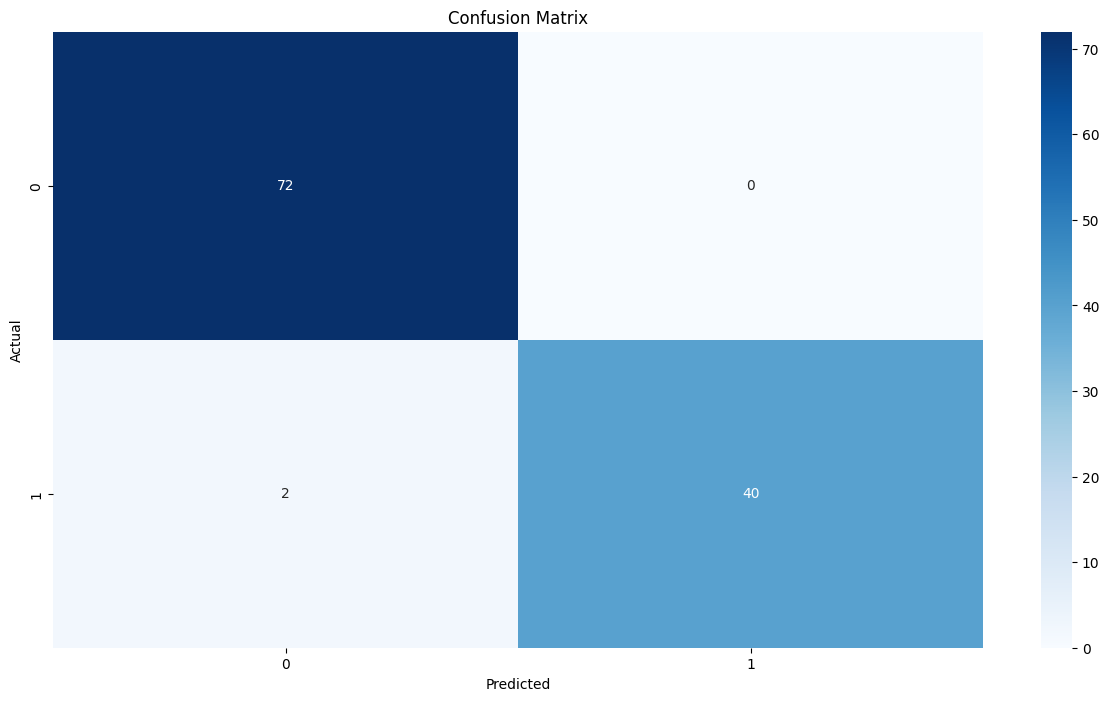

In [31]:
plt.figure(figsize=(15,8))
sns.heatmap(conf_mx,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#  Model Performance Comparison

To fairly evaluate each algorithm, **5-Fold Cross Validation** was used instead of relying on a single train-test split.

Cross Validation provides a more reliable estimate of a model's ability to generalize by evaluating it on multiple subsets of the data.

The following models are compared:

- Logistic Regression
- Linear Support Vector Machine
- Polynomial Support Vector Machine
- Radial Basis Function (RBF) Support Vector Machine
- Tuned RBF Support Vector Machine (GridSearchCV)

The comparison includes:

- Mean Cross Validation Accuracy
- Standard Deviation

Higher mean accuracy and lower standard deviation indicate a more accurate and stable model.

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Polynomial SVM",
        "RBF SVM",
        "Tuned RBF SVM"
    ],
    "Mean CV Accuracy": [
        log_reg_cv.mean(),
        linear_svm_cv.mean(),
        poly_svm_cv.mean(),
        rbf_svm_cv.mean(),
        tuned_rbf_svm_cv.mean()
    ],
    "Std Dev": [
        log_reg_cv.std(),
        linear_svm_cv.std(),
        poly_svm_cv.std(),
        rbf_svm_cv.std(),
        tuned_rbf_svm_cv.std()   # or use CV std from tuned model if you compute it
    ]
})

comparison = comparison.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

comparison

,Model,Mean CV Accuracy,Std Dev
4,Tuned RBF SVM,0.973626,0.013187
3,RBF SVM,0.973626,0.013187
1,Linear SVM,0.964835,0.017582
0,Logistic Regression,0.951648,0.022628
2,Polynomial SVM,0.901099,0.036776


#  Model Comparison Visualization

The following visualization summarizes the cross-validation performance of all evaluated models.

This allows us to quickly identify the most accurate classifier while comparing the performance differences between linear and nonlinear decision boundaries.

The RBF Kernel is expected to achieve the highest performance due to its ability to capture complex nonlinear relationships in the feature space.

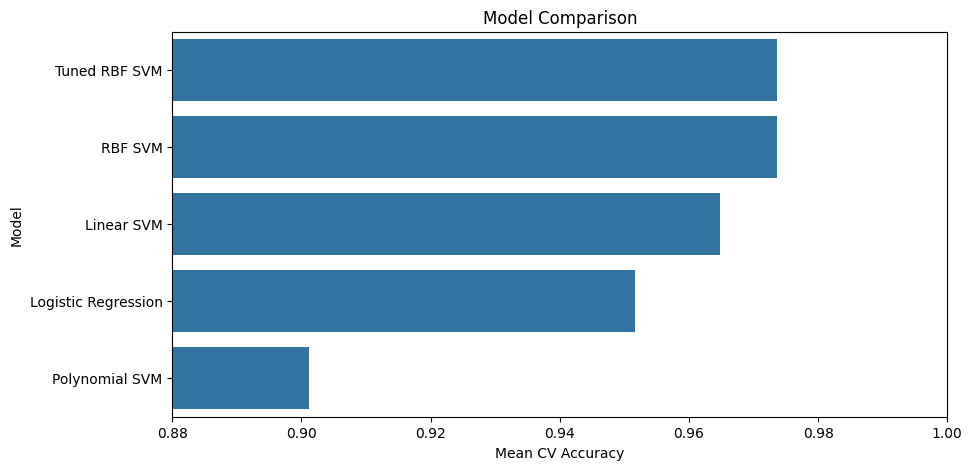

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Mean CV Accuracy",
    y="Model"
)

plt.xlim(0.88,1.0)

plt.title("Model Comparison")

plt.show()

#  Conclusion

This project explored the application of **Support Vector Machines (SVMs)** for breast cancer diagnosis using the Wisconsin Breast Cancer Diagnostic Dataset. Multiple machine learning models were evaluated using **5-Fold Cross Validation**, allowing a fair comparison of their generalization performance.

Among all evaluated models, the **RBF Support Vector Machine** achieved the best overall performance, demonstrating that nonlinear kernels can effectively capture complex decision boundaries while maintaining excellent generalization.

##  Final Model Comparison

| Model                  | Mean CV Accuracy | Standard Deviation |
| ---------------------- | ---------------: | -----------------: |
| 🥇 RBF SVM             |       **97.36%** |          **1.32%** |
| 🥇 Tuned RBF SVM       |       **97.36%** |          **1.32%** |
| 🥈 Linear SVM          |       **96.48%** |          **1.76%** |
| 🥉 Logistic Regression |       **95.16%** |          **2.26%** |
| Polynomial SVM         |       **90.11%** |          **3.68%** |

##  Best Model Performance

| Metric           |             Value |
| ---------------- | ----------------: |
| Best Model       | **Tuned RBF SVM** |
| Test Accuracy    |        **98.25%** |
| Mean CV Accuracy |        **97.36%** |
| Precision        |       **100.00%** |
| Recall           |        **95.24%** |
| F1 Score         |        **97.56%** |

##  Future Work

Potential improvements for this project include:

* Evaluate additional ensemble models such as Random Forest and XGBoost for comparison.
* Perform feature selection to identify the most influential tumor characteristics.
* Explore dimensionality reduction techniques such as PCA before SVM training.
* Investigate probability calibration for improved clinical interpretability.
* Validate the model on larger and independent breast cancer datasets to assess real-world generalization.


##  Key Takeaways

* Logistic Regression provided a strong linear baseline for comparison.
* Linear SVM outperformed Logistic Regression by maximizing the separating margin between classes.
* Polynomial SVM introduced additional complexity but produced lower accuracy and higher variability, indicating that increased model complexity does not necessarily improve performance.
* RBF SVM achieved the highest and most consistent performance by effectively modeling nonlinear decision boundaries.
* Hyperparameter tuning using GridSearchCV confirmed that the default RBF configuration was already close to optimal for this dataset.

Overall, this study demonstrates that **Support Vector Machines, particularly the RBF Kernel, are highly effective for medical classification tasks**, achieving excellent accuracy, precision, recall, and stability while maintaining strong generalization across multiple cross-validation folds.
